In [1]:

%load_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.io import loadmat, savemat
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
path_10MW = '/scratch/09909/smata/induction_modeling/gaussian_process/10MW/train_data/'
path_15MW = '/scratch/09909/smata/induction_modeling/gaussian_process/15MW/train_data/'
path_22MW = '/scratch/09909/smata/induction_modeling/gaussian_process/22MW/train_data/'
path_ALL  = '/scratch/09909/smata/induction_modeling/gaussian_process/all_turbines/train_data/'

In [4]:
mat_10MW = loadmat(path_10MW + 'wrf_10MW_ann_RAW.mat')
mat_15MW = loadmat(path_15MW + 'wrf_15MW_ann_RAW.mat')
mat_22MW = loadmat(path_22MW + 'wrf_22MW_ann_RAW.mat')
mat_ALL  = loadmat(path_ALL + 'wrf_all_ann_RAW.mat')

In [7]:
mat_10MW['X']

array([[ 0.04288751,  0.32147402, -0.03      , -0.2       ],
       [ 0.04288751,  0.32404799, -0.03      , -0.1       ],
       [ 0.04288751,  0.32418109, -0.03      , -0.05      ],
       ...,
       [ 0.98123309,  0.10782046,  0.03      ,  0.05      ],
       [ 0.98123309,  0.10818053,  0.03      ,  0.1       ],
       [ 0.98123309,  0.10839208,  0.03      ,  0.2       ]],
      shape=(1638, 4))

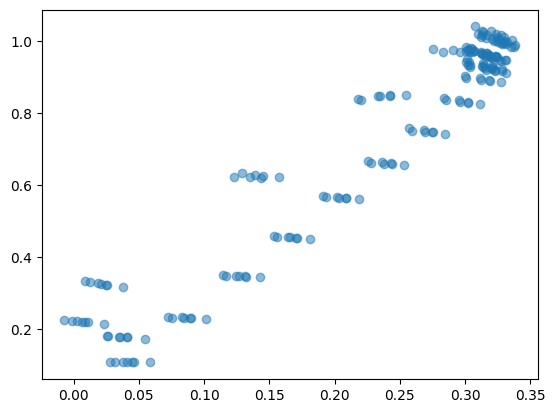

In [11]:
# Marginalize on shear, veer
# indices = [i for i, (r, ct, s, v) in enumerate(mat_10MW['X']) if (abs(s) == 0 and abs(v) == 0)]
indices = [i for i, (r, ct, s, v) in enumerate(mat_10MW['X']) if (abs(v) == 0)]

indices

plt.scatter(mat_10MW['y'][indices],mat_10MW['X'][indices,1] , alpha=0.5, zorder=2)

In [4]:
# mat_10MW['X'] = np.hstack([mat_10MW['X'],  (mat_10MW['X'][:,2] * mat_10MW['X'][:,0])[:, None], (mat_10MW['X'][:,3] * mat_10MW['X'][:,0])[:, None], (mat_10MW['X'][:,2] * mat_10MW['X'][:,1])[:, None], (mat_10MW['X'][:,3] * mat_10MW['X'][:,1])[:, None]])

# mat_15MW['X'] = np.hstack([mat_15MW['X'],  (mat_15MW['X'][:,2] * mat_15MW['X'][:,0])[:, None], (mat_15MW['X'][:,3] * mat_15MW['X'][:,0])[:, None], (mat_15MW['X'][:,2] * mat_15MW['X'][:,1])[:, None], (mat_15MW['X'][:,3] * mat_15MW['X'][:,1])[:, None]])

# mat_22MW['X'] = np.hstack([mat_22MW['X'],  (mat_22MW['X'][:,2] * mat_22MW['X'][:,0])[:, None], (mat_22MW['X'][:,3] * mat_22MW['X'][:,0])[:, None], (mat_22MW['X'][:,2] * mat_22MW['X'][:,1])[:, None], (mat_22MW['X'][:,3] * mat_22MW['X'][:,1])[:, None]])

mat_ALL['X'] = np.hstack([mat_ALL['X'],  (mat_ALL['X'][:,2] * mat_ALL['X'][:,0])[:, None], (mat_ALL['X'][:,3] * mat_ALL['X'][:,0])[:, None], (mat_ALL['X'][:,2] * mat_ALL['X'][:,1])[:, None], (mat_ALL['X'][:,3] * mat_ALL['X'][:,1])[:, None],      (mat_ALL['X'][:,2] * mat_ALL['X'][:,0]**2)[:, None], (mat_ALL['X'][:,3] * mat_ALL['X'][:,0]**2)[:, None],        (mat_ALL['X'][:,2]**2 * mat_ALL['X'][:,0])[:, None], (mat_ALL['X'][:,3]**2 * mat_ALL['X'][:,0])[:, None],      (mat_ALL['X'][:,2] * mat_ALL['X'][:,0]**3)[:, None], (mat_ALL['X'][:,3] * mat_ALL['X'][:,0]**3)[:, None]])

In [35]:
# Replace with your actual data
# X should be shape (N, 3), y should be shape (N,)

def analyze_inputs(X, y, variable_names=None):
    n_features = X.shape[1]

    if variable_names is None:
        variable_names = [f"x{i}" for i in range(n_features)]

    print("Basic statistics of input features:")
    for i, name in enumerate(variable_names):
        xi = X[:, i]
        print(f"{name}: mean={xi.mean():.4f}, std={xi.std():.4f}, min={xi.min():.4f}, max={xi.max():.4f}")

    print("\nCorrelation matrix (inputs + output):")
    all_data = np.hstack([X, y[:, None]])
    corr = np.corrcoef(all_data.T)
    labels = variable_names + ['$a$ [-]']

    # Create a mask to hide the diagonal
    mask = np.eye(corr.shape[0], dtype=bool)

    # Compute abs max excluding diagonal
    abs_max = np.abs(corr[~mask]).max()

    ax = sns.heatmap(
        corr,
        annot=True,
        xticklabels=labels,
        yticklabels=labels,
        cmap='seismic',
        center=0,
        vmin=-abs_max,
        vmax=abs_max,
        linewidths=0.5,
        square=True,
        mask=mask
    )

    # Make sure all spines (borders) are visible
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1.5)  # Optional: adjust thickness
        spine.set_color('black')  # Optional: adjust color

    plt.title("Correlation Matrix")
    plt.show()

    print("\nPlotting output vs each input:")
    for i, name in enumerate(variable_names):
        plt.scatter(X[:, i], y, alpha=0.5, zorder=2)
        plt.xlabel(name)
        plt.ylabel("Induction, $a$ [-]")
        plt.title(f"$a$ vs {name}")
        plt.grid(True)
        plt.show()


In [52]:
variable_names = ["$r/R$ [-]", "$C_T$ [-]", "Shear [1/s]", "Veer [deg/m]", "shear * r/R", "veer * r/R", "shear * CT", "veer * CT", "shear * r/R^2", "veer * r/R^2", "shear^2 * r/R", "veer^2 * r/R", "shear * r/R^3", "veer * r/R^3"]


# 10 MW Turbine

In [ ]:
analyze_inputs(mat_10MW['X'], mat_10MW['y'].ravel(),variable_names)

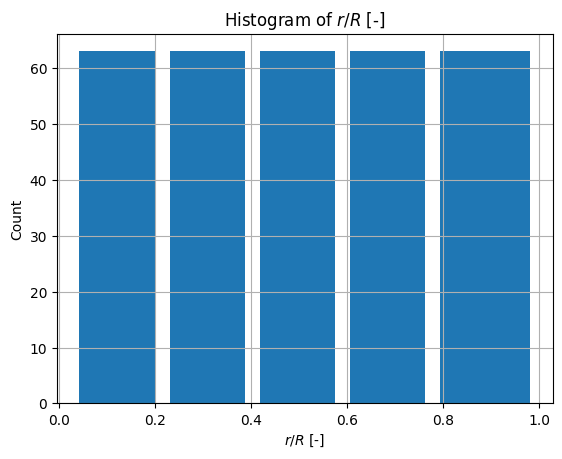

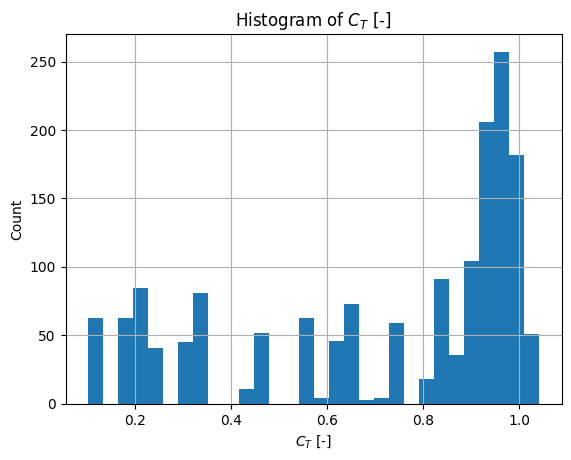

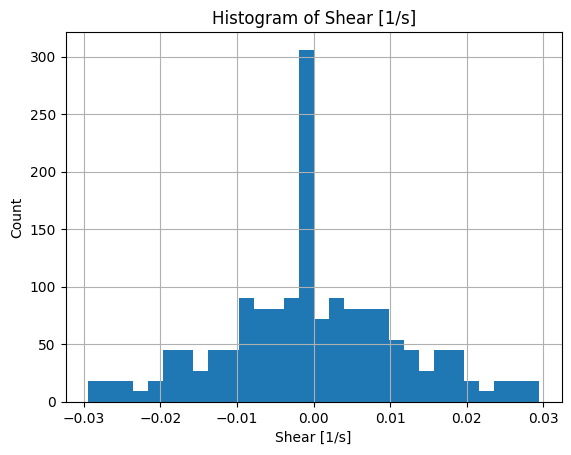

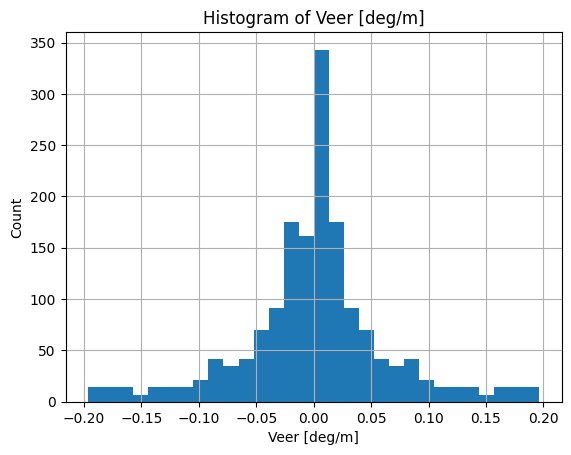

In [8]:
for i, name in enumerate(variable_names):
    plt.hist(mat_10MW['X'][:, i], bins=30)
    plt.title(f"Histogram of {name}")
    plt.xlabel(name)
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

In [9]:
X_design = sm.add_constant(mat_10MW['X'])
vifs = [variance_inflation_factor(X_design, i + 1) for i in range(mat_10MW['X'].shape[1])]
for name, vif in zip(variable_names, vifs):
    print(f"VIF for {name}: {vif:.2f}")

VIF for $r/R$ [-]: 1.03
VIF for $C_T$ [-]: 1.03
VIF for Shear [1/s]: 1.00
VIF for Veer [deg/m]: 1.00


/tmp/ipykernel_1253083/1907474693.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


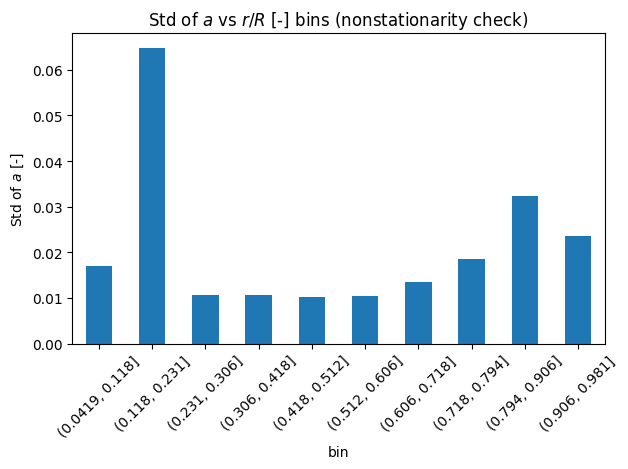

/tmp/ipykernel_1253083/1907474693.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


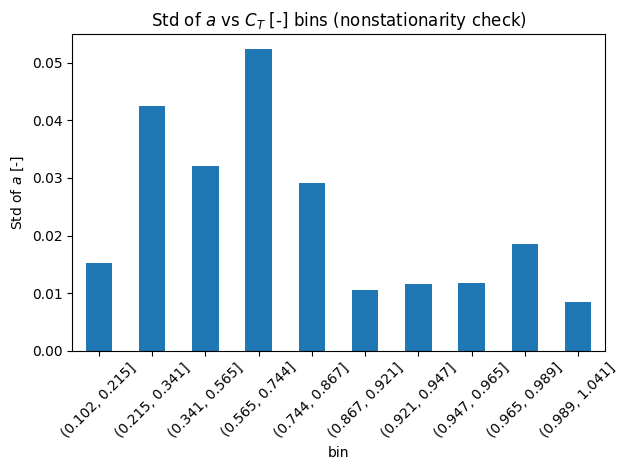

/tmp/ipykernel_1253083/1907474693.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


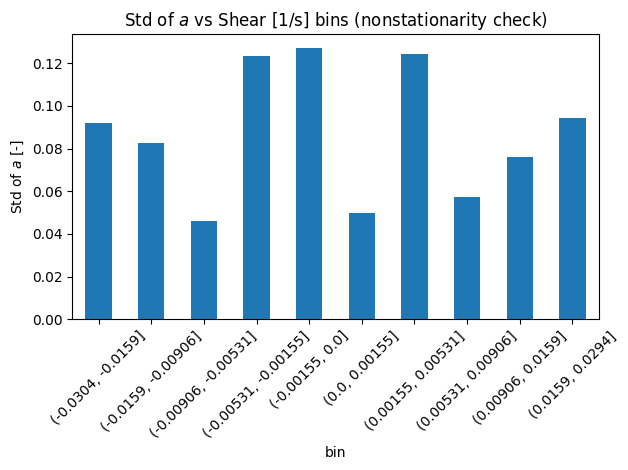

/tmp/ipykernel_1253083/1907474693.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


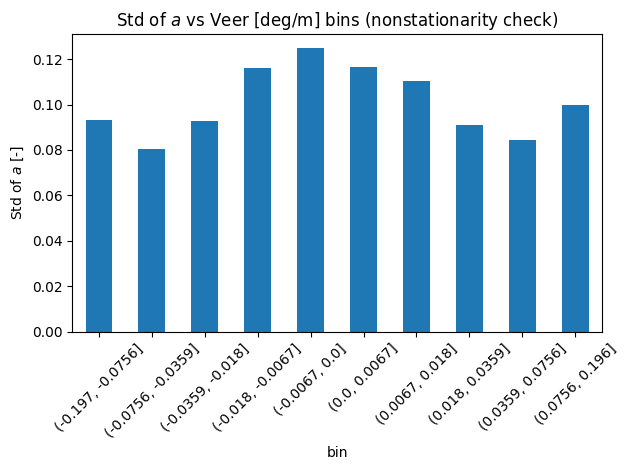

In [10]:
# Bin input and compute variance of y within each bin
for i, name in enumerate(variable_names):
    df = pd.DataFrame({name: mat_10MW['X'][:, i], 'y': mat_10MW['y'].ravel()})
    df['bin'] = pd.qcut(df[name], q=10, duplicates='drop')
    group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])
    group_stats.plot(y='std', kind='bar', legend=False)
    plt.title(f"Std of $a$ vs {name} bins (nonstationarity check)")
    plt.ylabel("Std of $a$ [-]")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 15MW Turbine

Basic statistics of input features:
$r/R$ [-]: mean=0.5163, std=0.2791, min=0.0478, max=0.9849
$C_T$ [-]: mean=0.7176, std=0.2558, min=0.0912, max=0.9289
Shear [1/s]: mean=0.0000, std=0.0117, min=-0.0295, max=0.0295
Veer [deg/m]: mean=0.0000, std=0.0638, min=-0.1970, max=0.1970

Correlation matrix (inputs + output):


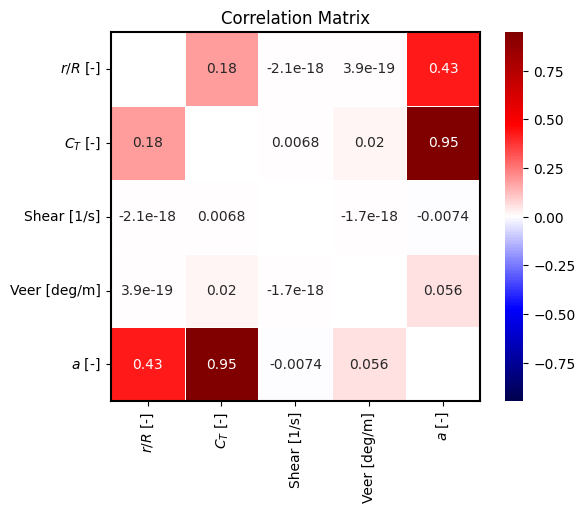


Plotting output vs each input:


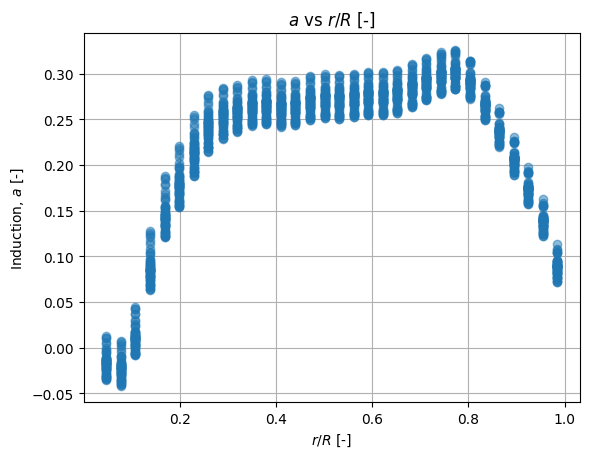

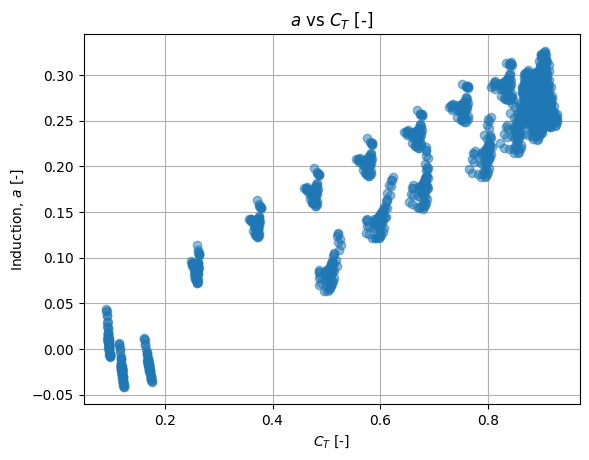

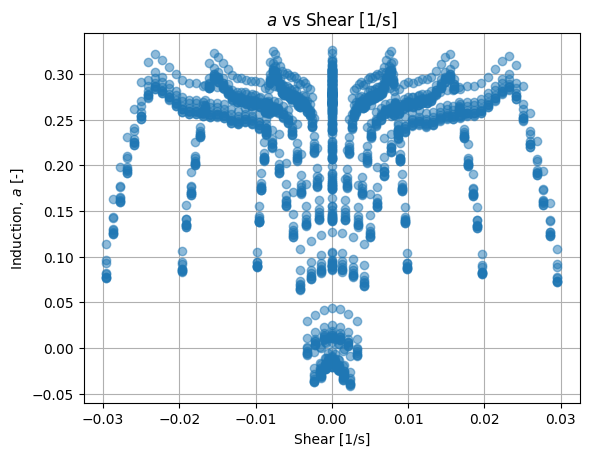

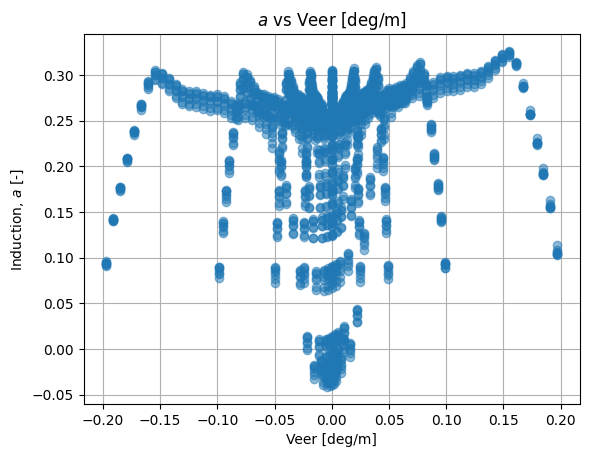

In [11]:
analyze_inputs(mat_15MW['X'], mat_15MW['y'].ravel(),variable_names)

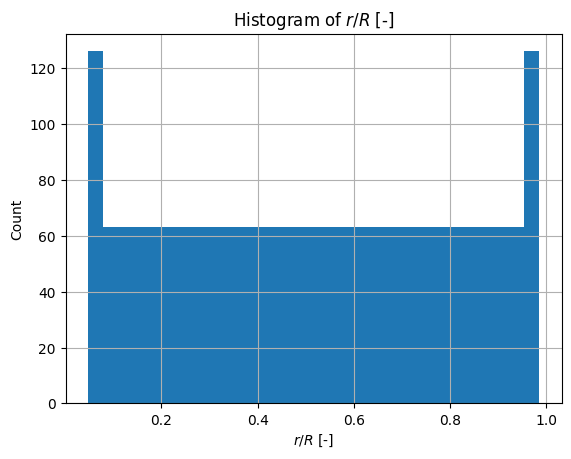

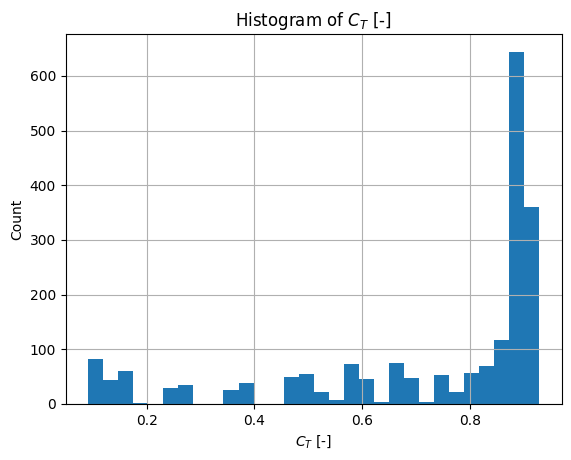

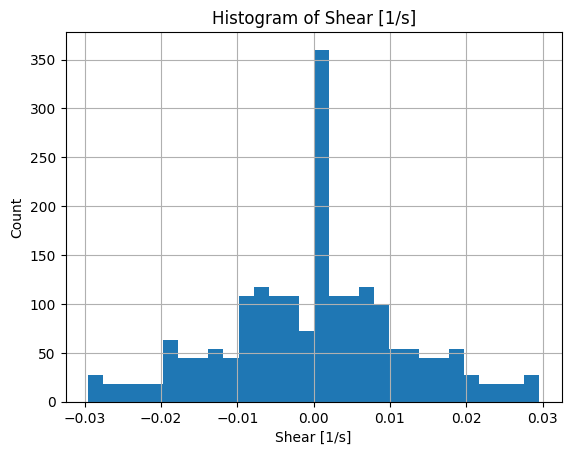

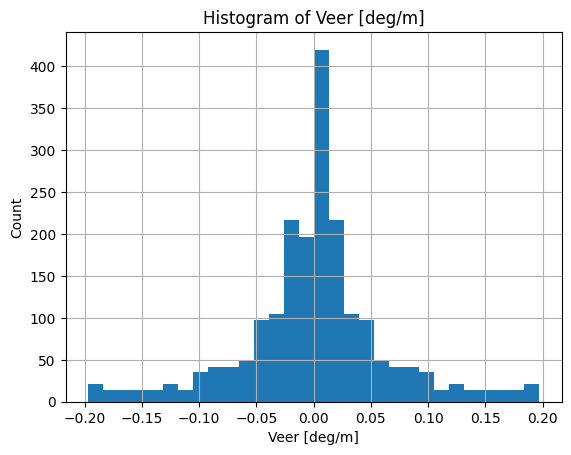

In [12]:
for i, name in enumerate(variable_names):
    plt.hist(mat_15MW['X'][:, i], bins=30)
    plt.title(f"Histogram of {name}")
    plt.xlabel(name)
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

In [13]:
X_design = sm.add_constant(mat_15MW['X'])
vifs = [variance_inflation_factor(X_design, i + 1) for i in range(mat_15MW['X'].shape[1])]
for name, vif in zip(variable_names, vifs):
    print(f"VIF for {name}: {vif:.2f}")

VIF for $r/R$ [-]: 1.03
VIF for $C_T$ [-]: 1.03
VIF for Shear [1/s]: 1.00
VIF for Veer [deg/m]: 1.00


/tmp/ipykernel_1253083/778330257.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


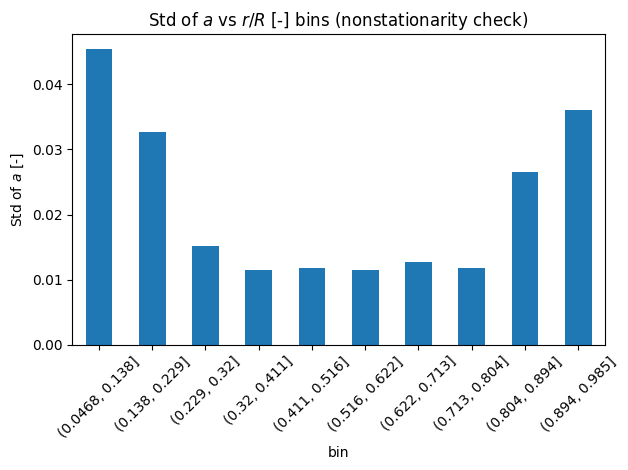

/tmp/ipykernel_1253083/778330257.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


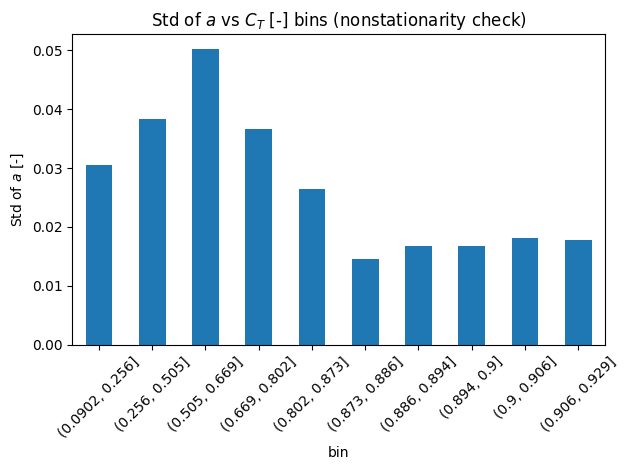

/tmp/ipykernel_1253083/778330257.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


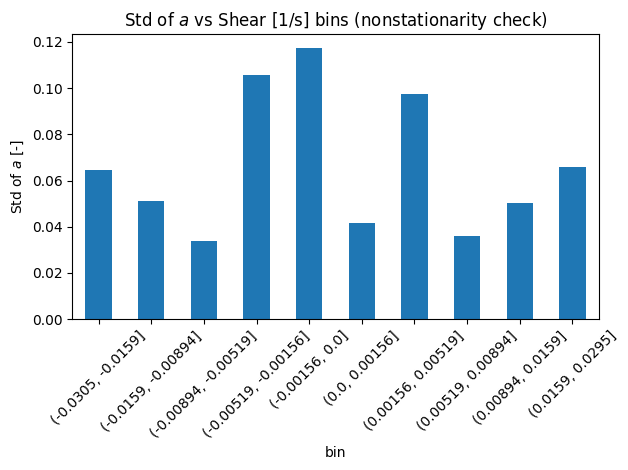

/tmp/ipykernel_1253083/778330257.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


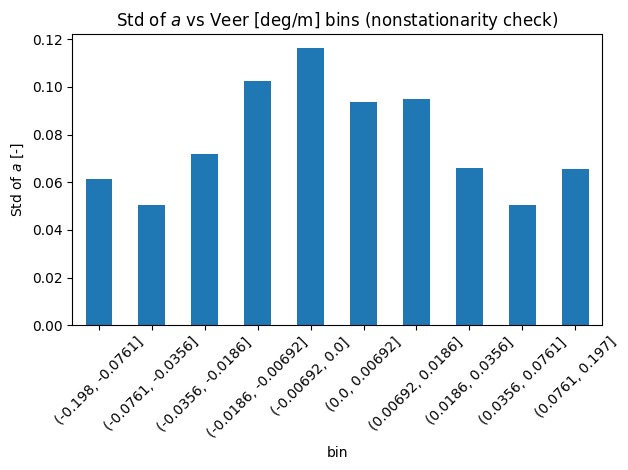

In [14]:
# Bin input and compute variance of y within each bin
for i, name in enumerate(variable_names):
    df = pd.DataFrame({name: mat_15MW['X'][:, i], 'y': mat_15MW['y'].ravel()})
    df['bin'] = pd.qcut(df[name], q=10, duplicates='drop')
    group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])
    group_stats.plot(y='std', kind='bar', legend=False)
    plt.title(f"Std of $a$ vs {name} bins (nonstationarity check)")
    plt.ylabel("Std of $a$ [-]")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 22MW Turbine

Basic statistics of input features:
$r/R$ [-]: mean=0.5148, std=0.2800, min=0.0427, max=0.9869
$C_T$ [-]: mean=0.7374, std=0.2241, min=0.1632, max=0.9488
Shear [1/s]: mean=0.0000, std=0.0117, min=-0.0296, max=0.0296
Veer [deg/m]: mean=0.0000, std=0.0637, min=-0.1974, max=0.1974

Correlation matrix (inputs + output):


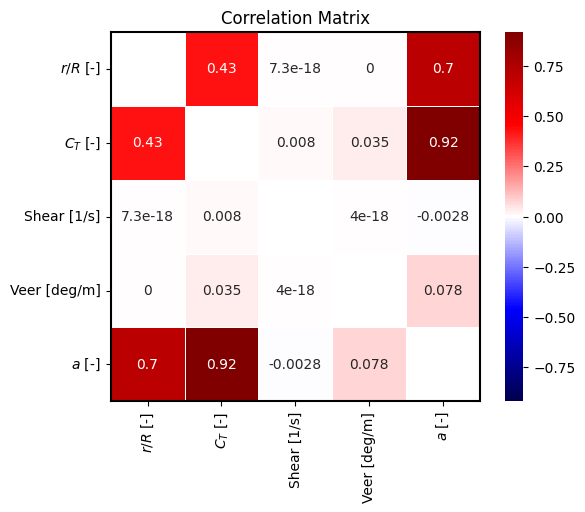


Plotting output vs each input:


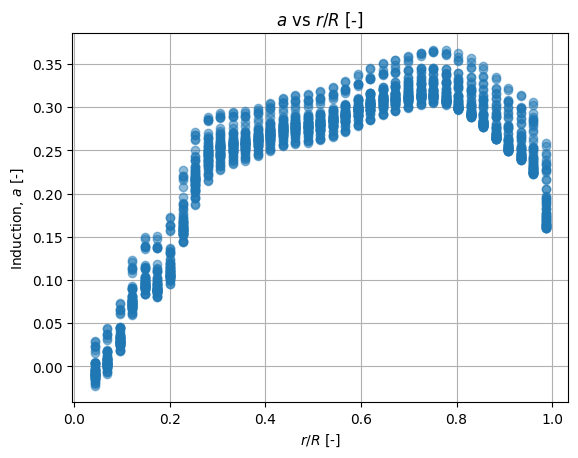

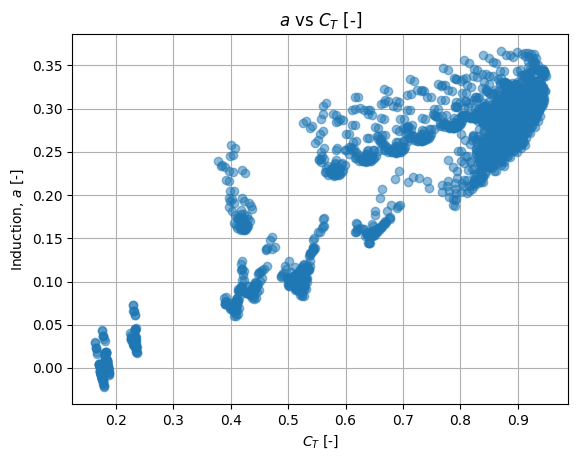

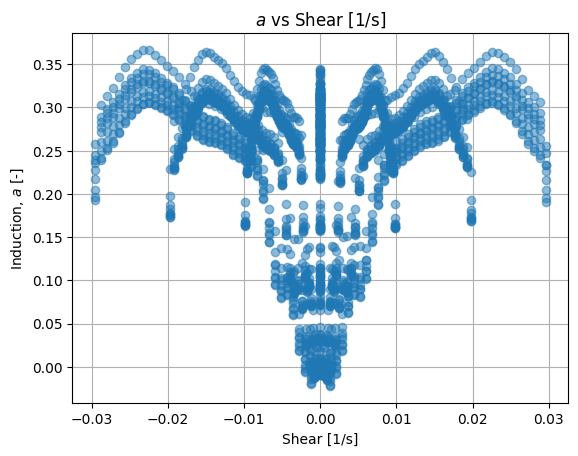

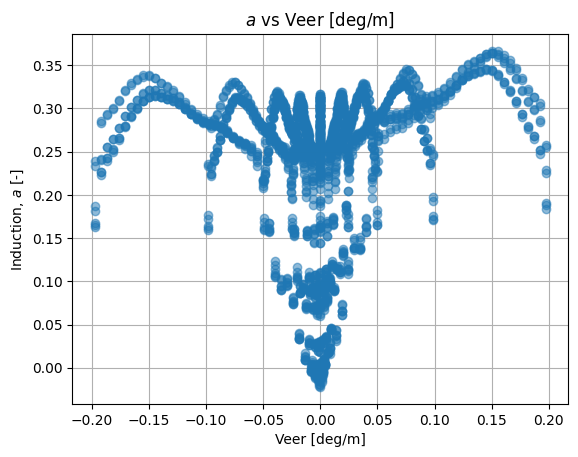

In [15]:
analyze_inputs(mat_22MW['X'], mat_22MW['y'].ravel(),variable_names)

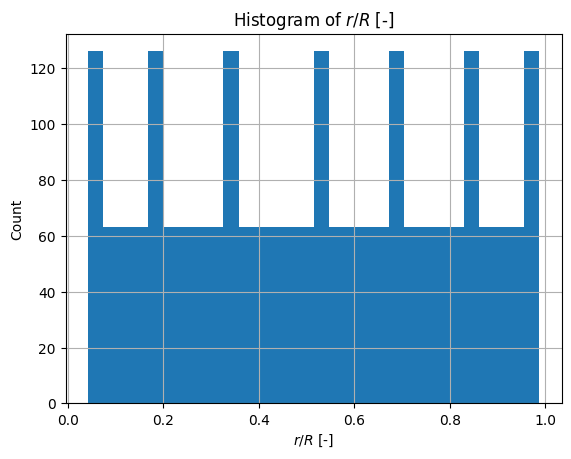

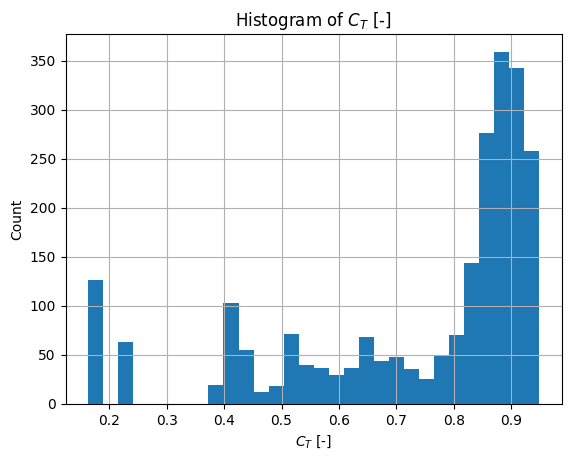

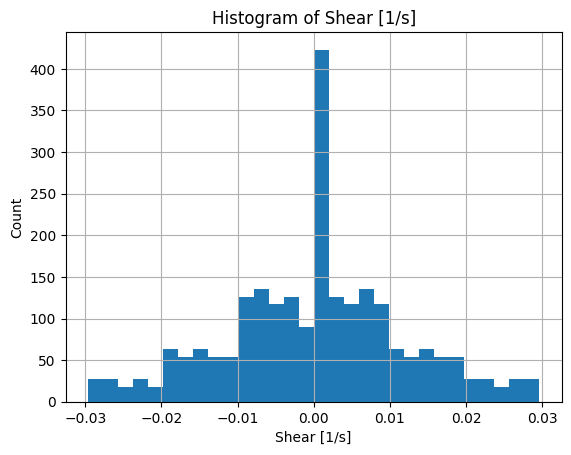

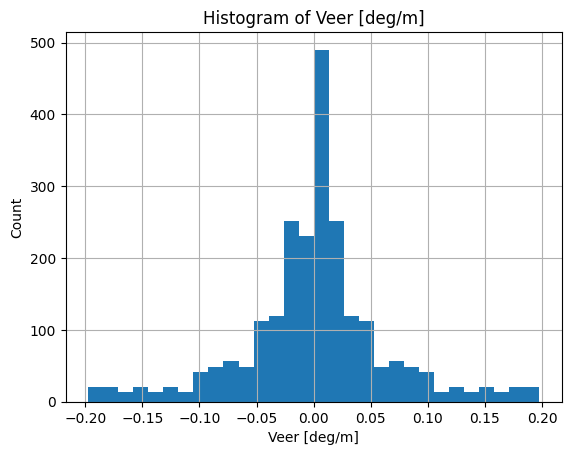

In [16]:
for i, name in enumerate(variable_names):
    plt.hist(mat_22MW['X'][:, i], bins=30)
    plt.title(f"Histogram of {name}")
    plt.xlabel(name)
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

In [17]:
X_design = sm.add_constant(mat_22MW['X'])
vifs = [variance_inflation_factor(X_design, i + 1) for i in range(mat_22MW['X'].shape[1])]
for name, vif in zip(variable_names, vifs):
    print(f"VIF for {name}: {vif:.2f}")

VIF for $r/R$ [-]: 1.22
VIF for $C_T$ [-]: 1.22
VIF for Shear [1/s]: 1.00
VIF for Veer [deg/m]: 1.00


/tmp/ipykernel_1253083/3251886510.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


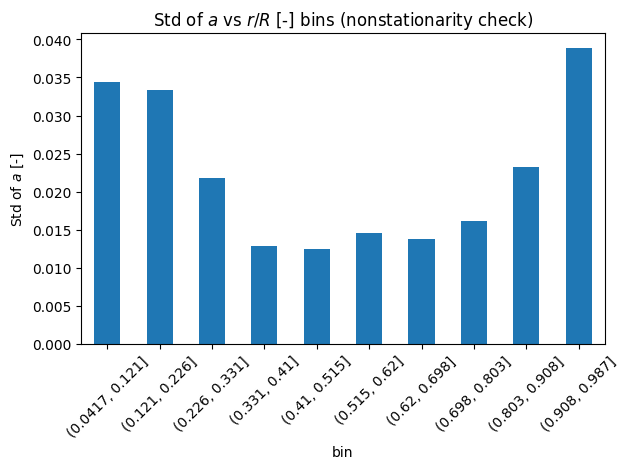

/tmp/ipykernel_1253083/3251886510.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


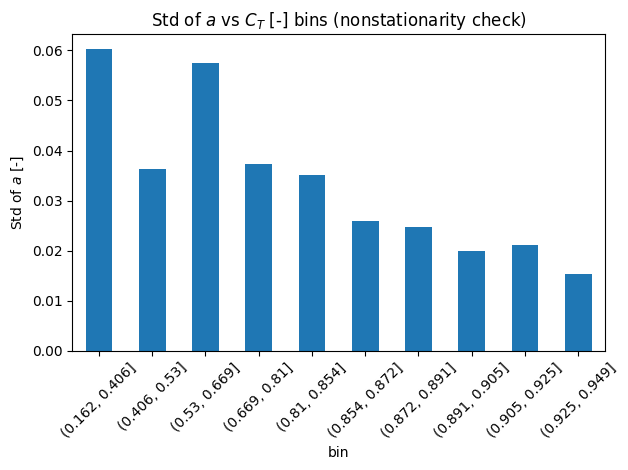

/tmp/ipykernel_1253083/3251886510.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


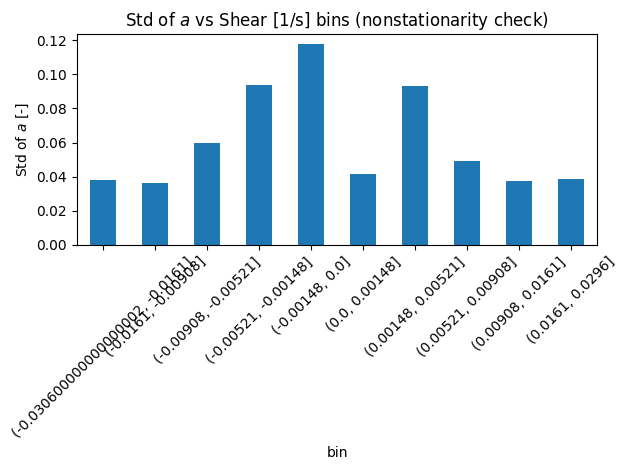

/tmp/ipykernel_1253083/3251886510.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


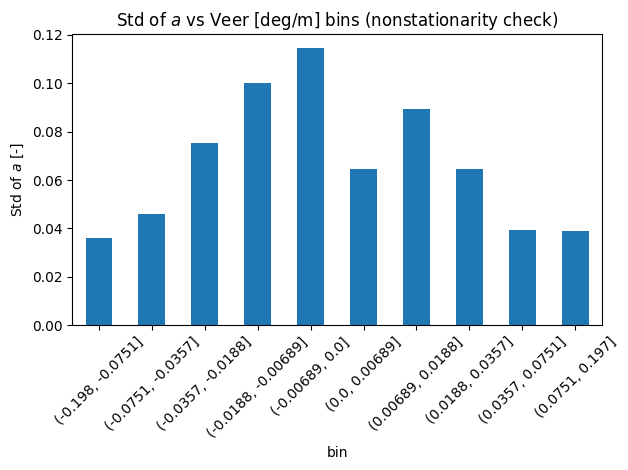

In [18]:
# Bin input and compute variance of y within each bin
for i, name in enumerate(variable_names):
    df = pd.DataFrame({name: mat_22MW['X'][:, i], 'y': mat_22MW['y'].ravel()})
    df['bin'] = pd.qcut(df[name], q=10, duplicates='drop')
    group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])
    group_stats.plot(y='std', kind='bar', legend=False)
    plt.title(f"Std of $a$ vs {name} bins (nonstationarity check)")
    plt.ylabel("Std of $a$ [-]")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# All turbines

Basic statistics of input features:
$r/R$ [-]: mean=0.5146, std=0.2801, min=0.0427, max=0.9869
$C_T$ [-]: mean=0.7237, std=0.2577, min=0.0912, max=1.0409
Shear [1/s]: mean=0.0000, std=0.0200, min=-0.0300, max=0.0300
Veer [deg/m]: mean=0.0000, std=0.1087, min=-0.2000, max=0.2000
shear * r/R: mean=0.0000, std=0.0117, min=-0.0296, max=0.0296
veer * r/R: mean=0.0000, std=0.0637, min=-0.1974, max=0.1974
shear * CT: mean=0.0000, std=0.0154, min=-0.0308, max=0.0312
veer * CT: mean=0.0006, std=0.0827, min=-0.2035, max=0.2030
shear * r/R^2: mean=0.0000, std=0.0091, min=-0.0292, max=0.0292
veer * r/R^2: mean=-0.0000, std=0.0493, min=-0.1948, max=0.1948
shear^2 * r/R: mean=0.0002, std=0.0002, min=0.0000, max=0.0009
veer^2 * r/R: mean=0.0061, std=0.0097, min=0.0000, max=0.0395
shear * r/R^3: mean=0.0000, std=0.0117, min=-0.0296, max=0.0296
veer * r/R^3: mean=0.0000, std=0.0637, min=-0.1974, max=0.1974

Correlation matrix (inputs + output):


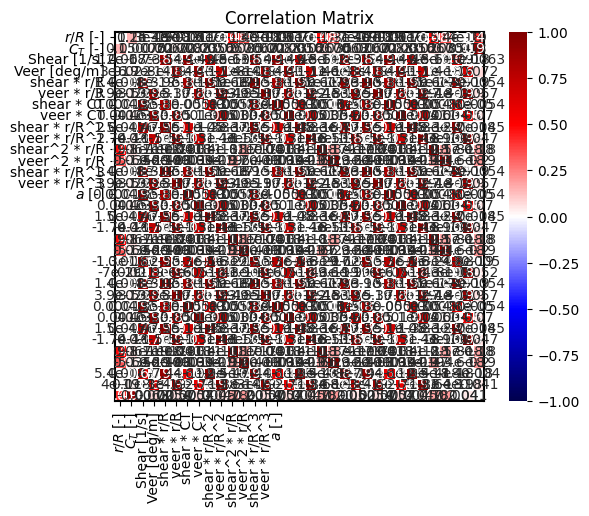


Plotting output vs each input:


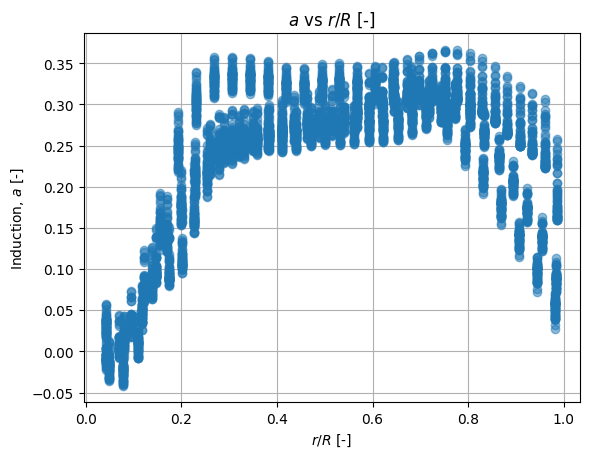

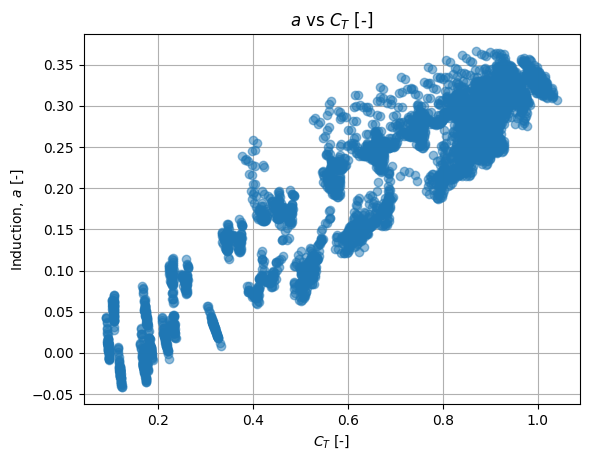

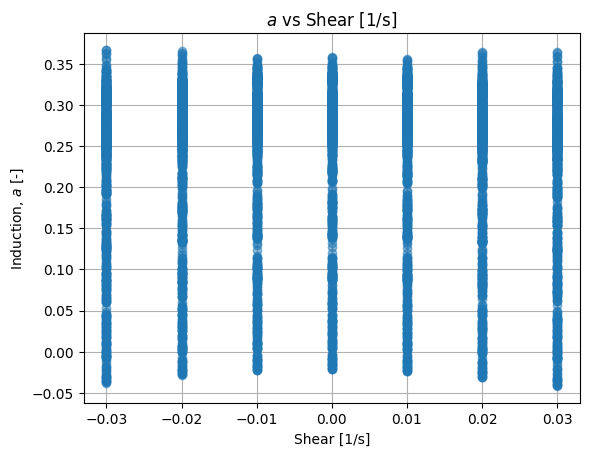

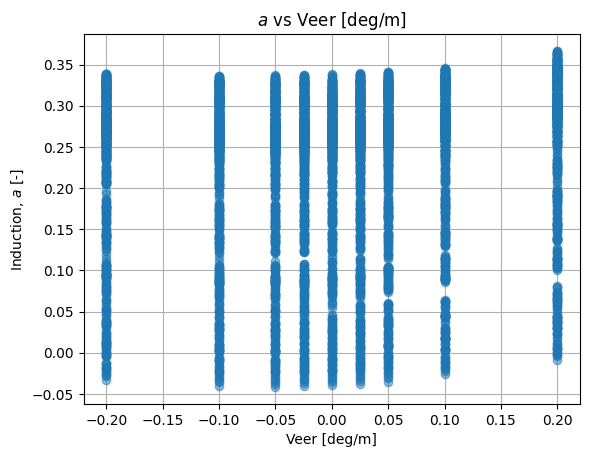

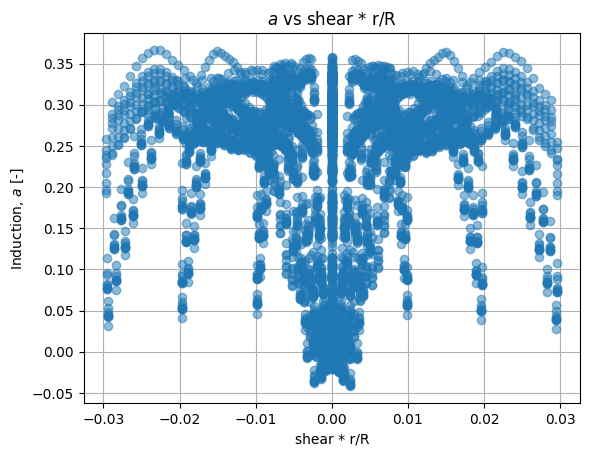

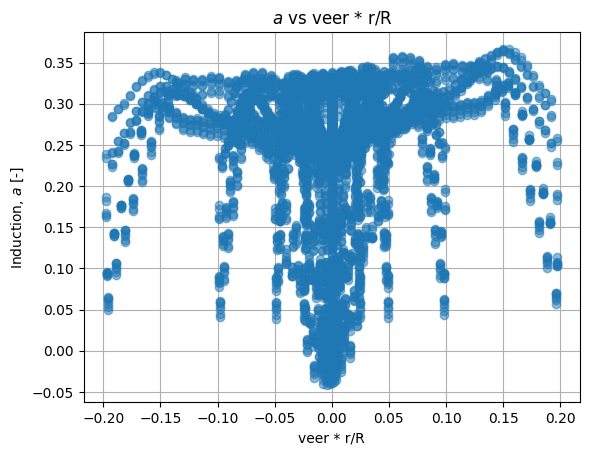

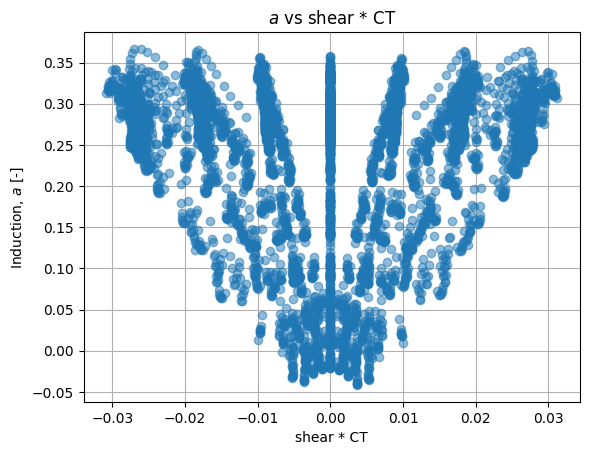

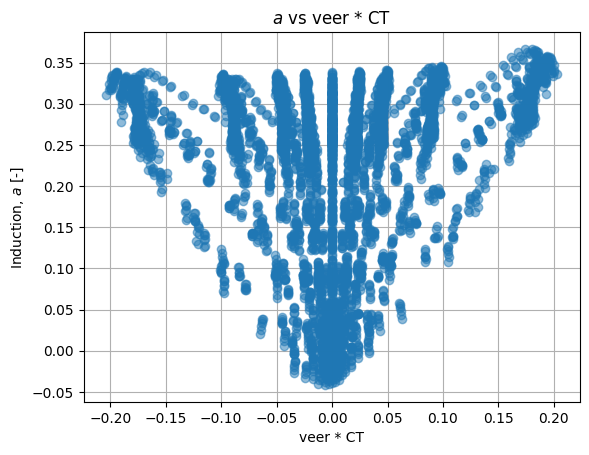

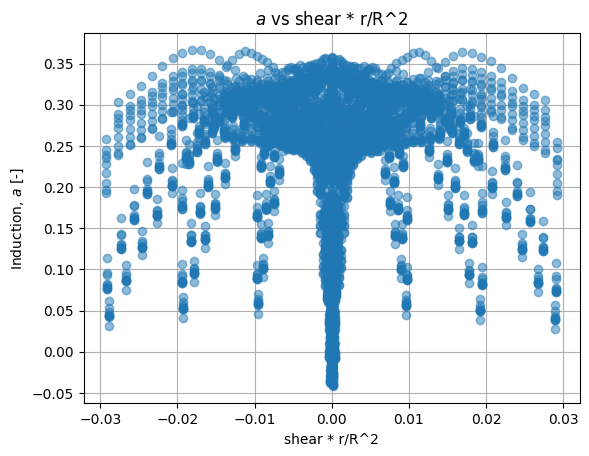

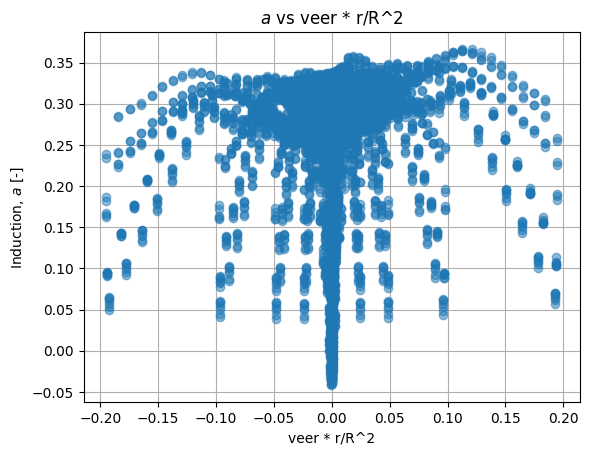

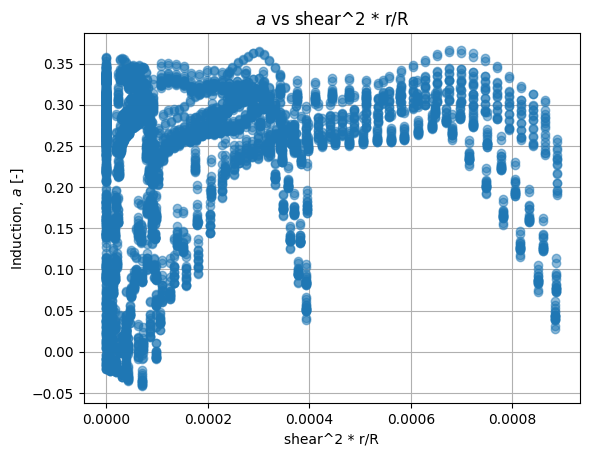

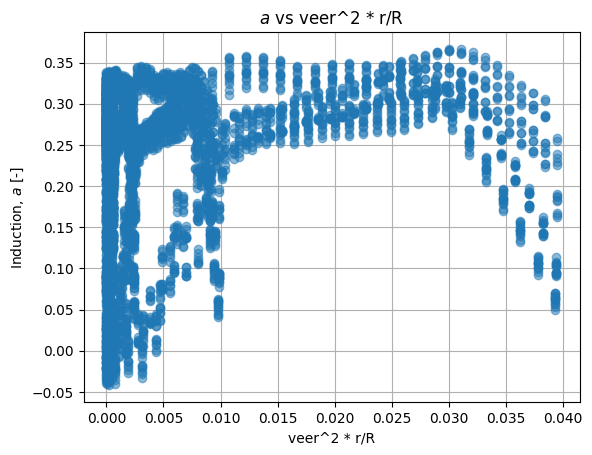

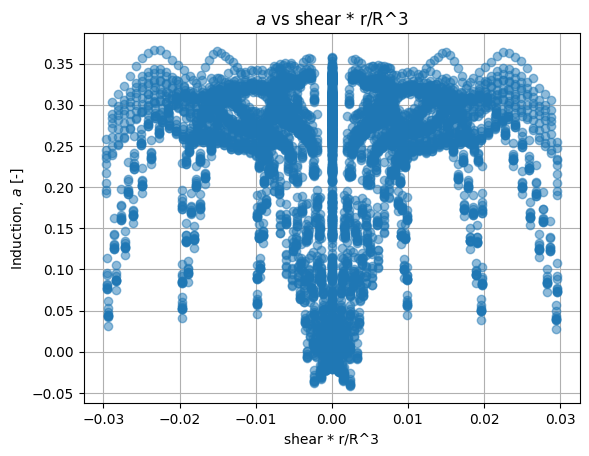

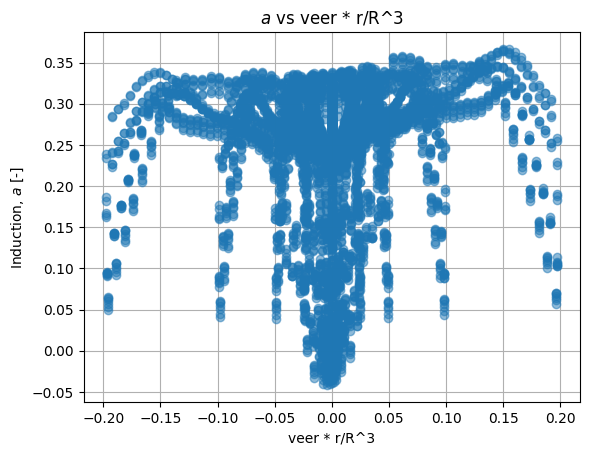

In [53]:
analyze_inputs(mat_ALL['X'], mat_ALL['y'].ravel(),variable_names)

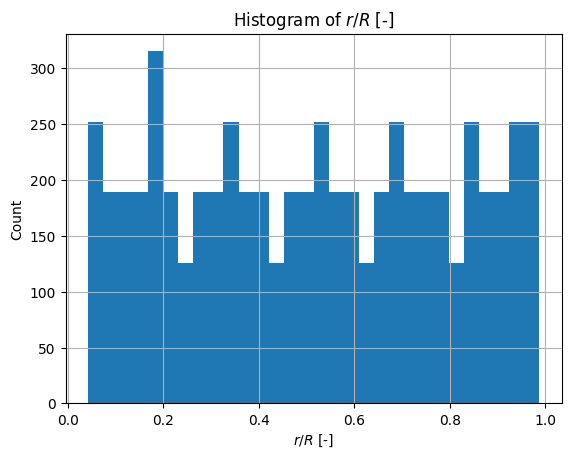

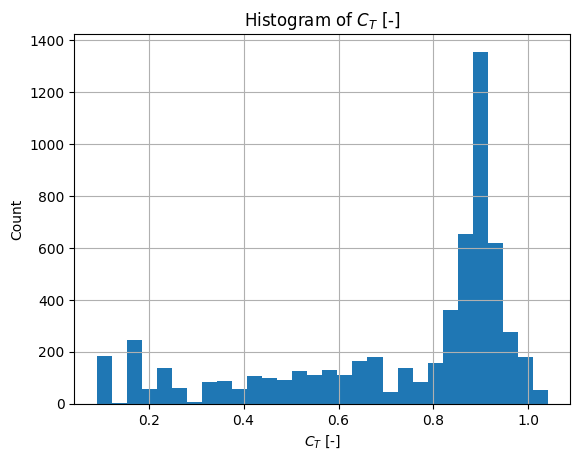

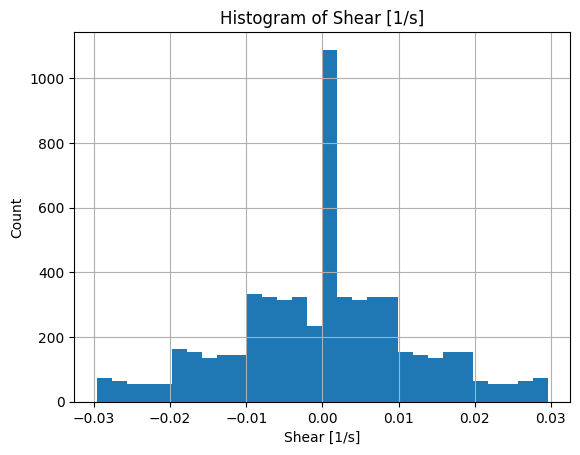

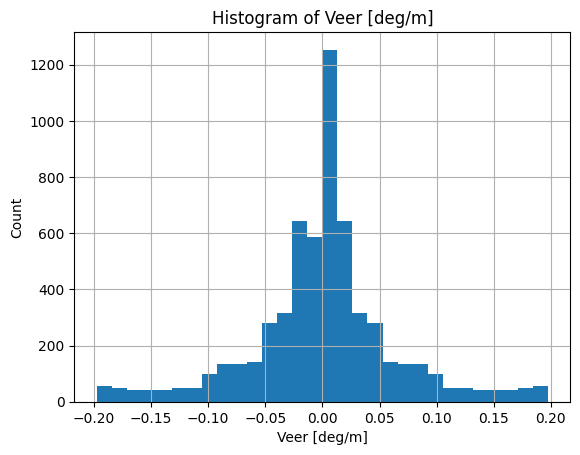

In [20]:
for i, name in enumerate(variable_names):
    plt.hist(mat_ALL['X'][:, i], bins=30)
    plt.title(f"Histogram of {name}")
    plt.xlabel(name)
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

In [21]:
X_design = sm.add_constant(mat_ALL['X'])
vifs = [variance_inflation_factor(X_design, i + 1) for i in range(mat_ALL['X'].shape[1])]
for name, vif in zip(variable_names, vifs):
    print(f"VIF for {name}: {vif:.2f}")

VIF for $r/R$ [-]: 1.02
VIF for $C_T$ [-]: 1.02
VIF for Shear [1/s]: 1.00
VIF for Veer [deg/m]: 1.00


/tmp/ipykernel_1253083/1163778189.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


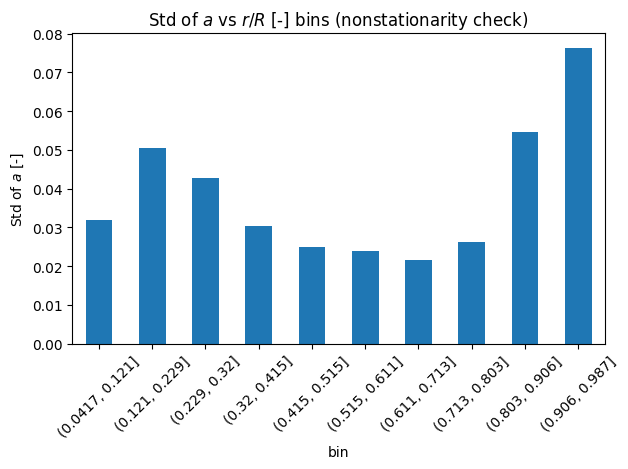

/tmp/ipykernel_1253083/1163778189.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


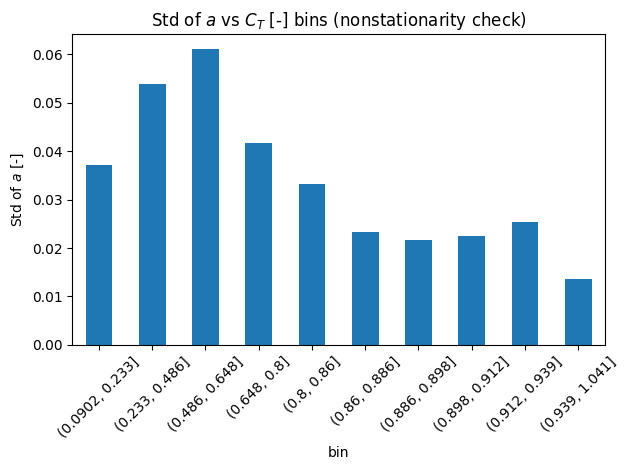

/tmp/ipykernel_1253083/1163778189.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


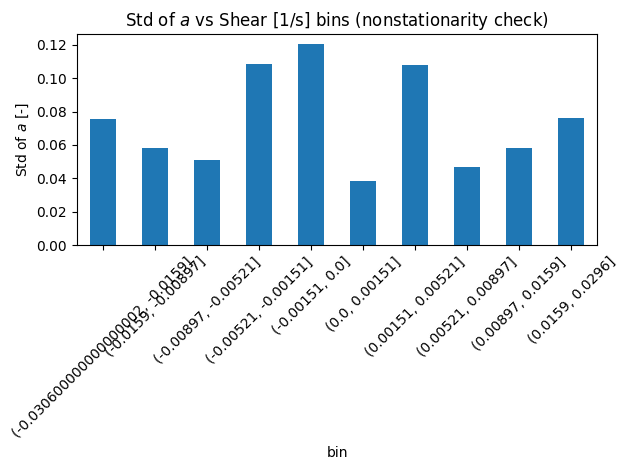

/tmp/ipykernel_1253083/1163778189.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


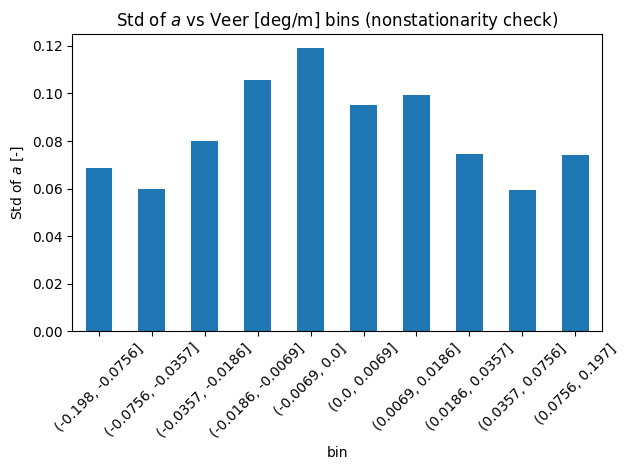

In [22]:
# Bin input and compute variance of y within each bin
for i, name in enumerate(variable_names):
    df = pd.DataFrame({name: mat_ALL['X'][:, i], 'y': mat_ALL['y'].ravel()})
    df['bin'] = pd.qcut(df[name], q=10, duplicates='drop')
    group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])
    group_stats.plot(y='std', kind='bar', legend=False)
    plt.title(f"Std of $a$ vs {name} bins (nonstationarity check)")
    plt.ylabel("Std of $a$ [-]")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

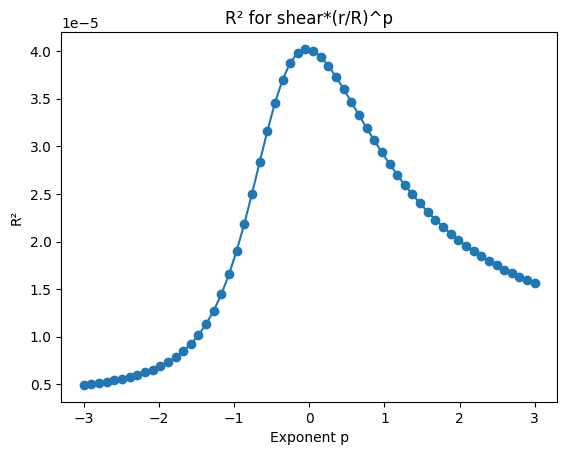

Best p: -0.051 with R²=0.000


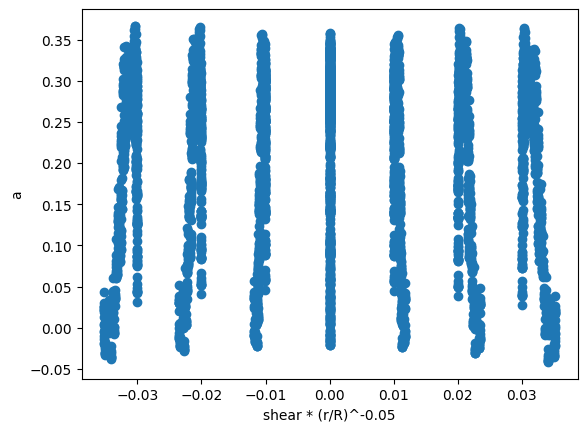

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Example arrays (replace with your own)
r_over_R = mat_ALL['X'][:,0].ravel()
shear    = mat_ALL['X'][:,2].ravel()
a        = mat_ALL['y'].ravel()

p_space = np.linspace(-3.0, 3.0, 60)
scores = []
best_score = -np.inf
best_p = None

for p in p_space:
    feat = shear * (r_over_R ** p)
    reg = LinearRegression().fit(feat.reshape(-1, 1), a)
    score = reg.score(feat.reshape(-1, 1), a)
    scores.append(score)
    if score > best_score:
        best_score = score
        best_p = p

# Visualize results
plt.plot(p_space, scores, '-o')
plt.xlabel('Exponent p')
plt.ylabel('R²')
plt.title('R² for shear*(r/R)^p')
plt.show()
print(f"Best p: {best_p:.3f} with R²={best_score:.3f}")

# Optionally, plot output against "flattened" best feature:
plt.scatter(shear * (r_over_R ** best_p), a)
plt.xlabel(f'shear * (r/R)^{best_p:.2f}')
plt.ylabel('a')
plt.show()

In [4]:
from pysr import PySRRegressor
os.cpu_count()

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


48

In [ ]:
# If not already installed, uncomment:
# !pip install pysr

# Example arrays (replace with your own)
r_over_R = mat_ALL['X'][:,0].ravel()
shear    = mat_ALL['X'][:,2].ravel()
# veer     = mat_ALL['X'][:,3].ravel()
a        = mat_ALL['y'].ravel()

X = np.column_stack([r_over_R, shear, veer])  # Add other variables as needed

model = PySRRegressor(
    niterations=1000,   # More iterations = deeper search
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["square", "cube", "sin", "cos", "exp", "log",],
    model_selection="best",
    procs=48,
    progress=True,
    verbosity=1,
    update_verbosity=10,
    output_directory="/scratch/09909/smata/temp/search_log.txt",  # All logs and equations go here
)
model.fit(X, a)

# View discovered equations:
for eqn in model.equations_:
    print(eqn)

# Use model.predict(X) to get predictions for new data

/work2/09909/smata/stampede3/miniconda3/envs/mitrotor/lib/python3.10/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
